2.1

1.设输入为 $\mathbf{x} \in \mathbb{R}^{d}$

隐藏层输出为  
$\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1$  
输出层为  
$\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$  
代入 $\mathbf{h}$ 得  
$\mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2 \mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)$  
定义  $\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1,\quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$  
则输出为 $\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'$，是一个单层线性网络。因此没有非线性激活函数的深层网络无法增加表达能力。

2.Sigmoid 函数：$\sigma(x) = \frac{1}{1+e^{-x}}$，导数 $\sigma'(x) = \sigma(x)(1-\sigma(x))$

tanh 函数：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$，导数 $\tanh'(x) = 1 - \tanh^2(x)$

In [9]:
# 2.2
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 超参数
batch_size = 256
input_size = 28*28
hidden_size = 256
num_classes = 10
lr = 0.1
epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 加载 Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 初始化参数（正态分布）
W1 = torch.randn(input_size, hidden_size, device=device) * 0.01
b1 = torch.zeros(hidden_size, device=device)
W2 = torch.randn(hidden_size, num_classes, device=device) * 0.01
b2 = torch.zeros(num_classes, device=device)

# ReLU
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# Softmax + 交叉熵
def cross_entropy_softmax(logits, y):
    # logits: (n, num_classes), y: (n,) 类别索引
    exp_logits = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss, probs

# 训练循环
def train_epoch():
    global W1, b1, W2, b2
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        # 前向
        h = relu(X @ W1 + b1)
        logits = h @ W2 + b2
        loss, probs = cross_entropy_softmax(logits, y)
        total_loss += loss.item()
        # 反向传播（手动计算梯度）
        # 输出层梯度
        dlogits = probs
        dlogits[range(len(y)), y] -= 1
        dlogits /= len(y)
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(dim=0)
        # 隐藏层梯度
        dh = dlogits @ W2.T
        dh[h <= 0] = 0   # ReLU 导数
        dW1 = X.T @ dh
        db1 = dh.sum(dim=0)
        # 更新参数
        with torch.no_grad():
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
    return total_loss / len(train_loader)

def evaluate():
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            h = relu(X @ W1 + b1)
            logits = h @ W2 + b2
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# 训练
for epoch in range(epochs):
    loss = train_epoch()
    acc = evaluate()
    print(f"Epoch {epoch+1}, loss={loss:.4f}, test acc={acc:.4f}")

100%|██████████| 26.4M/26.4M [00:07<00:00, 3.73MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.99MB/s]


Epoch 1, loss=1.0465, test acc=0.7438
Epoch 2, loss=0.6022, test acc=0.7963
Epoch 3, loss=0.5183, test acc=0.7906
Epoch 4, loss=0.4815, test acc=0.8206
Epoch 5, loss=0.4572, test acc=0.8165
Epoch 6, loss=0.4380, test acc=0.8376
Epoch 7, loss=0.4174, test acc=0.8347
Epoch 8, loss=0.4056, test acc=0.8181
Epoch 9, loss=0.3981, test acc=0.8472
Epoch 10, loss=0.3838, test acc=0.8247


3.1

1. 

训练误差：模型在训练数据集上的平均损失。  
泛化误差：模型在未见过的测试样本上的期望损失。  
当训练误差极低但泛化误差很高时，模型处于过拟合状态。

缓解方法：降低模型复杂度、增加数据量、使用正则化（L1/L2）、早停、Dropout等

2.
（1）将数据集随机划分为 $K$ 个大小相近的子集。  
（2）对 $i=1,\dots,K$：  
   第 $i$ 个子集作为验证集，其余 $K-1$ 个作为训练集  
   训练模型并在验证集上评估性能
   
（3）计算 $K$ 次评估指标的平均值作为最终估计

Using device: cpu
实验1：无正则化
Epoch  10, Train Loss: 1.4412, Val Loss: 1.6152
Epoch  20, Train Loss: 0.8918, Val Loss: 1.1241
Epoch  30, Train Loss: 0.6901, Val Loss: 0.9540
Epoch  40, Train Loss: 0.5396, Val Loss: 0.8559
Epoch  50, Train Loss: 0.4796, Val Loss: 0.8106
Epoch  60, Train Loss: 0.3486, Val Loss: 0.8875
Epoch  70, Train Loss: 0.3101, Val Loss: 0.8049
Epoch  80, Train Loss: 0.2551, Val Loss: 0.7502
Epoch  90, Train Loss: 0.2276, Val Loss: 0.7339
Epoch 100, Train Loss: 0.1766, Val Loss: 0.8381

实验2：仅权重衰减 (λ = 0.001)
Epoch  10, Train Loss: 1.3959, Val Loss: 1.4565
Epoch  20, Train Loss: 0.8761, Val Loss: 1.0659
Epoch  30, Train Loss: 0.6381, Val Loss: 0.8870
Epoch  40, Train Loss: 0.5074, Val Loss: 0.8334
Epoch  50, Train Loss: 0.3786, Val Loss: 0.8572
Epoch  60, Train Loss: 0.3778, Val Loss: 0.8257
Epoch  70, Train Loss: 0.3151, Val Loss: 0.8830
Epoch  80, Train Loss: 0.2755, Val Loss: 0.8800
Epoch  90, Train Loss: 0.2240, Val Loss: 0.8129
Epoch 100, Train Loss: 0.1801, Val Los

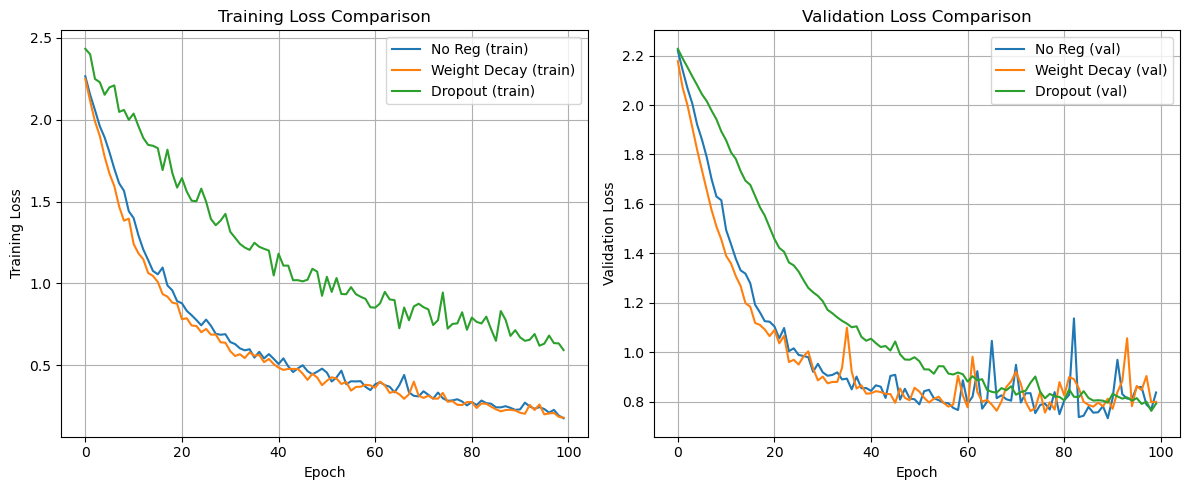


观察结论：
- 无正则化: 训练损失持续下降至接近0，但验证损失在后期上升 → 过拟合
- 权重衰减: 训练损失下降较慢，验证损失相对稳定，泛化更好
- Dropout:  类似权重衰减，也有效抑制过拟合


In [10]:
#3.2
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子，保证可复现
torch.manual_seed(42)
np.random.seed(42)

# 设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 超参数
input_size = 28 * 28
hidden_sizes = [512, 512, 512]   # 三个隐藏层，宽度 512（复杂模型）
num_classes = 10
batch_size = 32
lr = 0.01
epochs = 100
weight_decay_lambda = 0.001        # L2 正则化系数 λ
dropout_rate = 0.5                 # Dropout 丢弃概率

# 加载 Fashion-MNIST，但只取极少量样本（200 训练 + 200 验证）
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
full_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 从训练集中随机取 200 个作为训练集，再从剩余中取 200 个作为验证集
indices = list(range(len(full_train)))
np.random.shuffle(indices)
train_indices = indices[:200]
val_indices = indices[200:400]

train_set = torch.utils.data.Subset(full_train, train_indices)
val_set = torch.utils.data.Subset(full_train, val_indices)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)

# 为了对比，测试集保持原样（但这里只用验证误差曲线，不测最终准确率）
# 我们只关心训练和验证的 loss 曲线

# 定义 MLP 模型（使用 nn.Module 便于管理参数，但梯度更新依然手动）
class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers.append(torch.nn.Linear(prev, h))
            prev = h
        layers.append(torch.nn.Linear(prev, num_classes))
        self.net = torch.nn.Sequential(*layers)
        # 初始化权重（Xavier 初始化）
        for m in self.net.modules():
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                torch.nn.init.zeros_(m.bias)
    def forward(self, x, dropout_rate=0.0, is_training=True):
        # 手动逐层前向，以便在隐藏层后插入 dropout
        h = x
        for i, layer in enumerate(self.net):
            h = layer(h)
            if i < len(self.net) - 1:   # 最后一个 Linear 之后不加激活和 dropout
                h = torch.relu(h)
                if is_training and dropout_rate > 0:
                    h = self.dropout_layer(h, dropout_rate)
        return h
    
    def dropout_layer(self, X, dropout):
        # 从零实现 dropout，训练时随机置零并缩放
        mask = (torch.rand(X.shape, device=X.device) > dropout).float()
        return X * mask / (1.0 - dropout)

# ------------------------------------------------------------
# 训练函数（支持权重衰减和 dropout）
# ------------------------------------------------------------
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay_lambda, dropout_rate, device):
    train_losses = []
    val_losses = []
    
    # 定义损失函数（交叉熵）
    criterion = torch.nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            # 前向（训练模式，启用 dropout）
            logits = model(X, dropout_rate=dropout_rate, is_training=True)
            loss = criterion(logits, y)
            total_loss += loss.item()
            
            # 手动反向传播
            model.zero_grad()
            loss.backward()
            
            # 手动 SGD 更新（带权重衰减）
            with torch.no_grad():
                for param in model.parameters():
                    # 权重衰减：梯度加上 λ * w
                    # 标准 SGD: w = w - lr * (grad + λ * w)
                    grad = param.grad
                    if weight_decay_lambda > 0:
                        grad = grad + weight_decay_lambda * param.data
                    param.data -= lr * grad
        
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X, dropout_rate=0.0, is_training=False)
                loss = criterion(logits, y)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses

# 1. 无正则化（无权重衰减，无 dropout）
print("="*50)
print("实验1：无正则化")
model1 = MLP(input_size, hidden_sizes, num_classes).to(device)
train_loss1, val_loss1 = train_model(model1, train_loader, val_loader, epochs, lr, 
                                     weight_decay_lambda=0.0, dropout_rate=0.0, device=device)

# 2. 仅有权重衰减（L2 正则化）
print("\n" + "="*50)
print("实验2：仅权重衰减 (λ = {})".format(weight_decay_lambda))
model2 = MLP(input_size, hidden_sizes, num_classes).to(device)
train_loss2, val_loss2 = train_model(model2, train_loader, val_loader, epochs, lr, 
                                     weight_decay_lambda=weight_decay_lambda, dropout_rate=0.0, device=device)

# 3. 仅有 Dropout
print("\n" + "="*50)
print("实验3：仅 Dropout (rate = {})".format(dropout_rate))
model3 = MLP(input_size, hidden_sizes, num_classes).to(device)
train_loss3, val_loss3 = train_model(model3, train_loader, val_loader, epochs, lr, 
                                     weight_decay_lambda=0.0, dropout_rate=dropout_rate, device=device)

# 绘制对比曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss1, label='No Reg (train)')
plt.plot(train_loss2, label='Weight Decay (train)')
plt.plot(train_loss3, label='Dropout (train)')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_loss1, label='No Reg (val)')
plt.plot(val_loss2, label='Weight Decay (val)')
plt.plot(val_loss3, label='Dropout (val)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n观察结论：")
print("- 无正则化: 训练损失持续下降至接近0，但验证损失在后期上升 → 过拟合")
print("- 权重衰减: 训练损失下降较慢，验证损失相对稳定，泛化更好")
print("- Dropout:  类似权重衰减，也有效抑制过拟合")

4.1

1. 
反向传播中梯度连乘：$\frac{\partial L}{\partial \mathbf{h}^t} = \frac{\partial L}{\partial \mathbf{h}^d} \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}$，其中 $\frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \mathbf{W}_i^\top \operatorname{diag}(\sigma'(\mathbf{h}^i))$。  
- 梯度爆炸：当权重矩阵特征值 $>1$ 且激活函数导数不很小（如线性区）时，连乘指数增长。  
- 梯度消失：当特征值 $<1$ 或激活函数导数始终 $\ll 1$（如 Sigmoid 最大导数 0.25）时，连乘指数衰减。

2.
ReLU 在正半轴导数为 1，负半轴导数为 0。正半轴上梯度可以无衰减地传递，避免了因多次乘小于1的数而消失。虽然负半轴梯度为0，但整体上减轻了指数衰减问题。

In [11]:
#4.2
import torch
import torch.nn as nn

# 构建20层全连接网络
class DeepNet(nn.Module):
    def __init__(self, activation=nn.Sigmoid, init_func=None):
        super().__init__()
        layers = []
        for i in range(20):
            layers.append(nn.Linear(256, 256))
            if activation:
                layers.append(activation())
        self.net = nn.Sequential(*layers)
        if init_func:
            self.apply(init_func)
    def forward(self, x):
        return self.net(x)

# 记录每层梯度范数
def compute_grad_norms(model, x):
    model.zero_grad()
    out = model(x)
    out.mean().backward()
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append(param.grad.norm().item())
    return norms

# 1) Sigmoid + N(0,1) 初始化，观察梯度消失
model1 = DeepNet(activation=nn.Sigmoid, init_func=lambda m: nn.init.normal_(m.weight, mean=0, std=1) if isinstance(m, nn.Linear) else None)
x = torch.randn(64, 256)
norms = compute_grad_norms(model1, x)
print("Sigmoid + N(0,1) 梯度范数（前几层 vs 后几层）:", norms[:3], "…", norms[-3:])   # 后几层很小

# 2) ReLU + 大初始化 (std=10) 观察 NaN
model2 = DeepNet(activation=nn.ReLU, init_func=lambda m: nn.init.normal_(m.weight, mean=0, std=10) if isinstance(m, nn.Linear) else None)
x = torch.randn(64, 256)
try:
    out = model2(x)
    loss = out.mean()
    loss.backward()
    print("ReLU + std=10 梯度范数（部分）:", compute_grad_norms(model2, x)[:3])
except Exception as e:
    print("出现 NaN 或爆炸:", e)

# 3) Xavier 初始化 + ReLU 稳定
model3 = DeepNet(activation=nn.ReLU, init_func=lambda m: nn.init.xavier_uniform_(m.weight) if isinstance(m, nn.Linear) else None)
norms = compute_grad_norms(model3, x)
print("Xavier + ReLU 梯度范数:", norms[:3], "…", norms[-3:])   # 稳定在合理范围

Sigmoid + N(0,1) 梯度范数（前几层 vs 后几层）: [0.46376433968544006, 0.3183630704879761, 0.285614013671875] … [0.03137660771608353, 0.031991150230169296, 0.03743943199515343]
ReLU + std=10 梯度范数（部分）: [inf, inf, inf]
Xavier + ReLU 梯度范数: [0.00014776423631701618, 0.00024020469572860748, 0.00032460506190545857] … [0.012142510153353214, 0.01979689486324787, 0.026362478733062744]


5.1

协变量偏移：$p(\mathbf{x}) \neq q(\mathbf{x})$ 但 $p(y|\mathbf{x}) = q(y|\mathbf{x})$。  
实例：医疗诊断中训练数据来自年轻患者，测试时为老年患者（输入分布变），但症状与疾病的对应关系不变。

标签偏移：$p(y) \neq q(y)$ 但 $p(\mathbf{x}|y) = q(\mathbf{x}|y)$。  
实例：电商推荐中训练时某类商品点击率高，测试时该类点击率下降（输出分布变），但给定商品类别后用户特征分布不变。

联系与区别：两者都表示训练与测试分布不一致。区别在于偏移发生在输入边际分布还是输出边际分布。校正方法不同：协变量偏移用重要性加权 $\frac{p(\mathbf{x})}{q(\mathbf{x})}$，标签偏移需估计 $\frac{p(y)}{q(y)}$。

In [12]:
#5.2
import numpy as np
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression

# 1. 生成数据
np.random.seed(42)
n_train = 1000
n_test = 500
# 训练集 P: x ~ N(-1,1)
x_train = np.random.normal(-1, 1, size=(n_train, 1))
y_train = 2 * x_train + 0.1 * np.random.randn(n_train, 1)
# 测试集 Q: x ~ N(2,1)
x_test = np.random.normal(2, 1, size=(n_test, 1))
y_test = 2 * x_test + 0.1 * np.random.randn(n_test, 1)

# 2. 基线模型：线性回归（普通最小二乘）
from sklearn.linear_model import LinearRegression
model_base = LinearRegression().fit(x_train, y_train)
mse_base = np.mean((model_base.predict(x_test) - y_test)**2)
print(f"基线 MSE: {mse_base:.4f}")

# 3. 协变量偏移校正：训练分类器区分训练/测试样本
X_combined = np.vstack([x_train, x_test])
y_combined = np.array([0]*n_train + [1]*n_test)  # 0:训练,1:测试
clf = LogisticRegression().fit(X_combined, y_combined)
# 预测每个训练样本属于测试集的概率 P(test|x)
prob_test_train = clf.predict_proba(x_train)[:, 1]   # 属于测试集的概率
prob_train = 1 - prob_test_train                     # P(train|x)
# 计算权重 w_i = P(test|x_i) / P(train|x_i)
weights = prob_test_train / (prob_train + 1e-8)
weights = weights / weights.sum() * len(weights)     # 归一化

# 4. 加权线性回归（加权最小二乘）
# 手动实现加权损失：L = sum w_i * (y_i - (w x_i + b))^2
X_aug = np.hstack([x_train, np.ones((n_train,1))])   # 添加偏置列
# 解析解: theta = (X^T diag(w) X)^{-1} X^T diag(w) y
W_diag = np.diag(weights)
theta = np.linalg.inv(X_aug.T @ W_diag @ X_aug) @ X_aug.T @ W_diag @ y_train
y_pred_weighted = x_test * theta[0] + theta[1]
mse_weighted = np.mean((y_pred_weighted - y_test)**2)
print(f"加权校正后 MSE: {mse_weighted:.4f}")

基线 MSE: 0.0102
加权校正后 MSE: 0.0240
